In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("student_habits_performance-selected-columns.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [4]:
df.shape

(1000, 16)

# EDA

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
sns.set(style="whitegrid")

In [7]:
df.isna().sum().sum()

np.int64(91)

In [8]:
df = df.dropna()

In [9]:
df.isna().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
import warnings
warnings. filterwarnings("ignore")

In [12]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000
mean,20.475248,3.538724,2.504620,1.830363,83.880308,6.474037,3.051705,5.466447,69.558196
std,2.302721,1.469730,1.164802,1.071251,9.453622,1.218943,2.035632,2.857525,16.929436
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.000000,2.500000,1.700000,1.000000,77.500000,5.600000,1.000000,3.000000,58.400000
50%,20.000000,3.500000,2.500000,1.800000,84.200000,6.500000,3.000000,5.000000,70.400000
75%,22.000000,4.500000,3.300000,2.600000,90.700000,7.300000,5.000000,8.000000,81.300000
max,24.000000,8.300000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [14]:
df.describe(include="object").columns

Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='object')

In [15]:
categorical_cols=['gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation']

In [17]:
for col in categorical_cols:
  print(f"Value counts for {col}: \n {df[col].value_counts()}")

Value counts for gender: 
 gender
Male      440
Female    433
Other      36
Name: count, dtype: int64
Value counts for part_time_job: 
 part_time_job
No     713
Yes    196
Name: count, dtype: int64
Value counts for diet_quality: 
 diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64
Value counts for parental_education_level: 
 parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
Value counts for internet_quality: 
 internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64
Value counts for extracurricular_participation: 
 extracurricular_participation
No     620
Yes    289
Name: count, dtype: int64


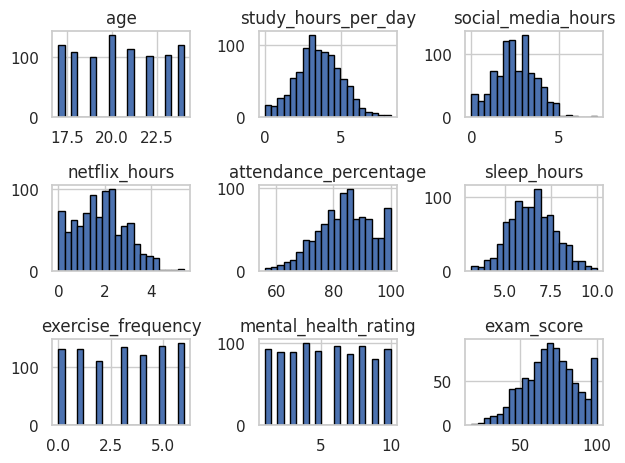

In [18]:
df.hist(bins=20, edgecolor="black")
plt.tight_layout()
plt.show()

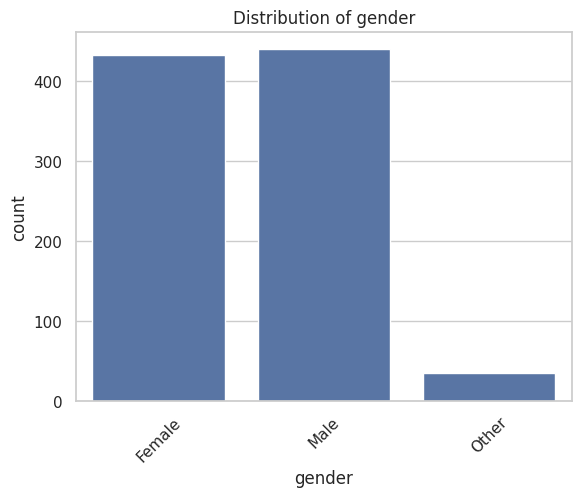

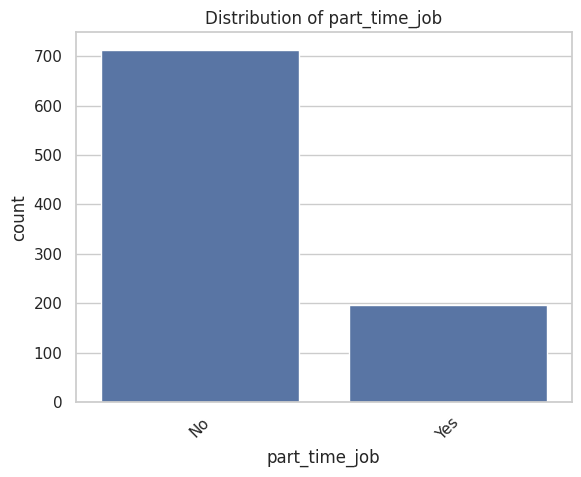

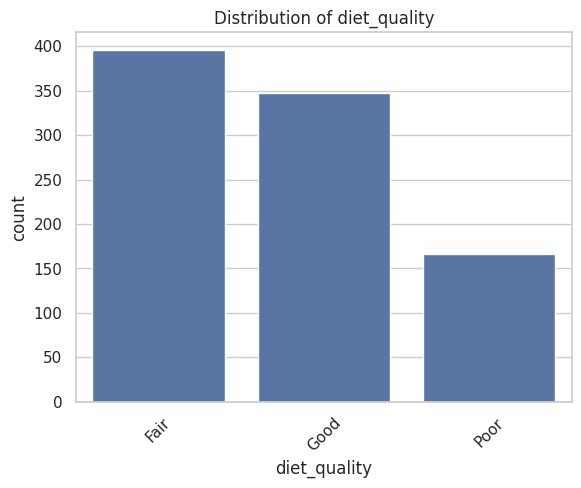

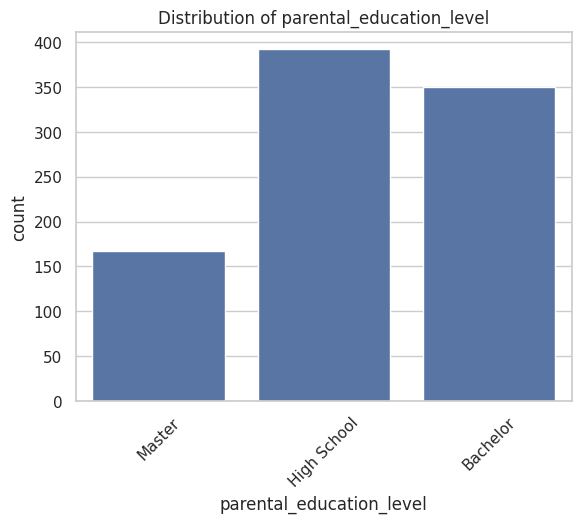

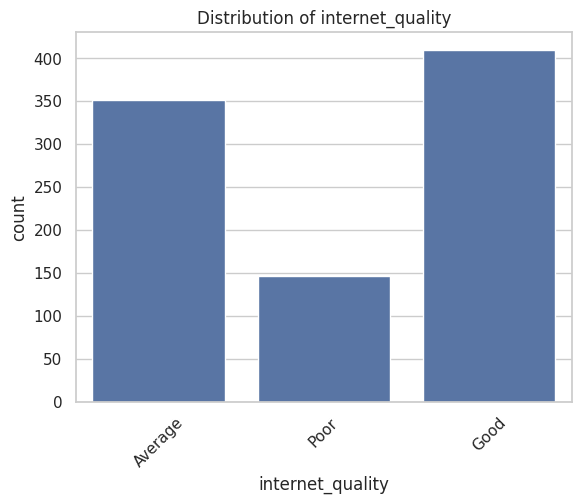

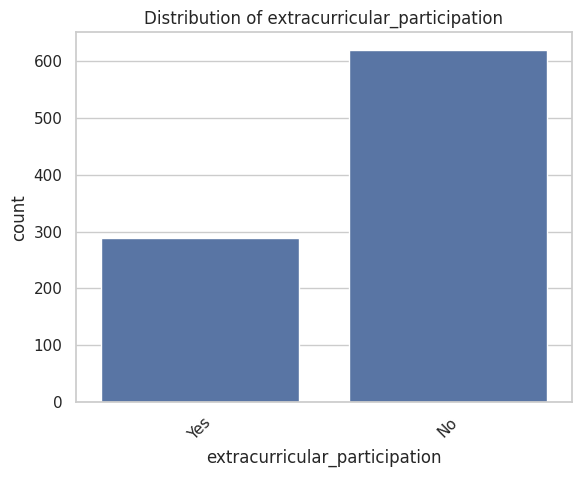

In [20]:
for col in categorical_cols:
    sns.countplot(data=df, x = col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation = 45)
    plt.show()

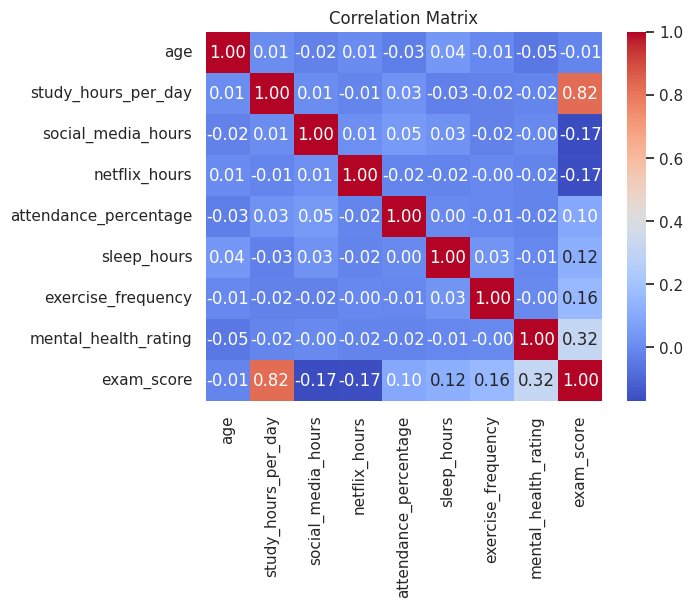

In [22]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [23]:
df.describe().columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

In [24]:
num_features=['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating']

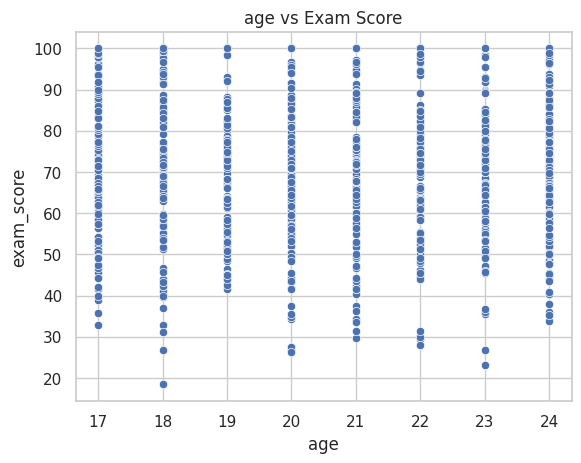

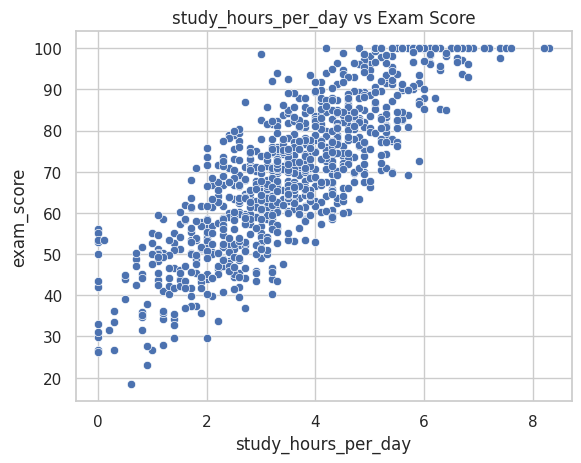

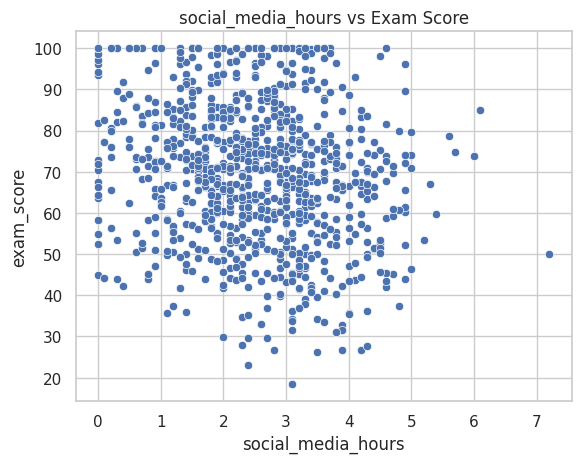

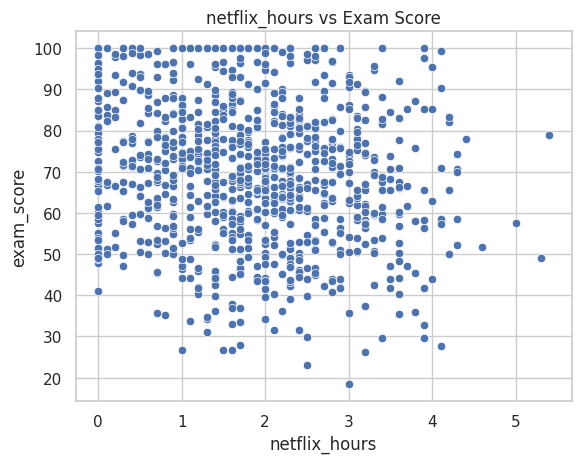

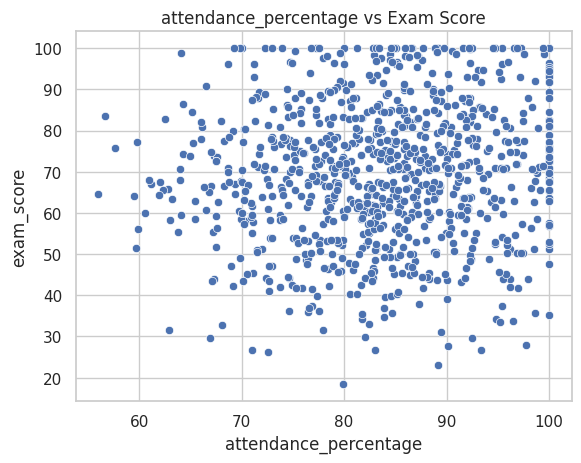

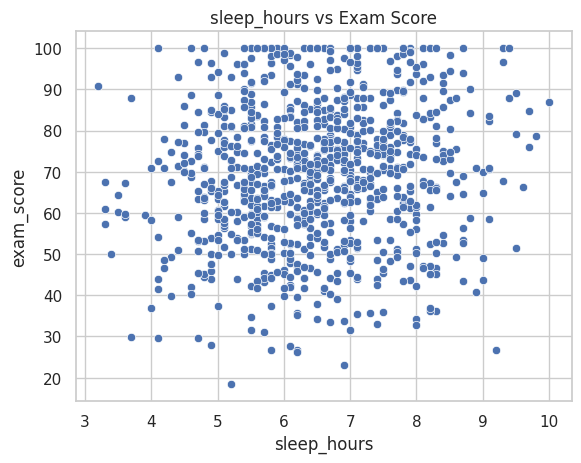

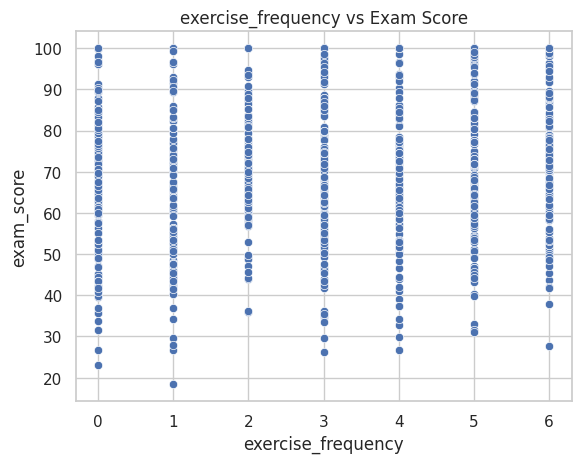

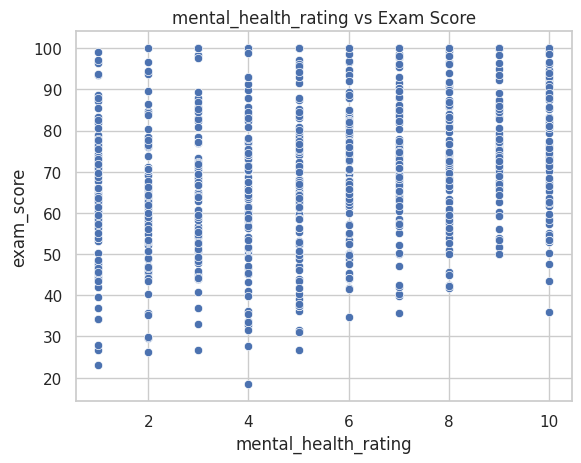

In [25]:
for feature in num_features:
    sns.scatterplot(data = df, x = feature, y = "exam_score")
    plt.title(f"{feature} vs Exam Score")
    plt.show()

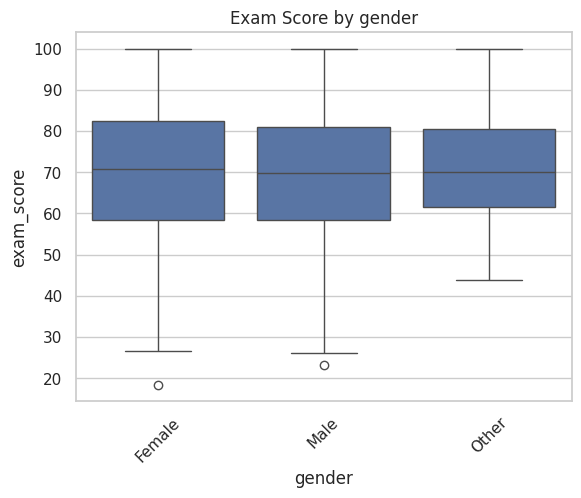

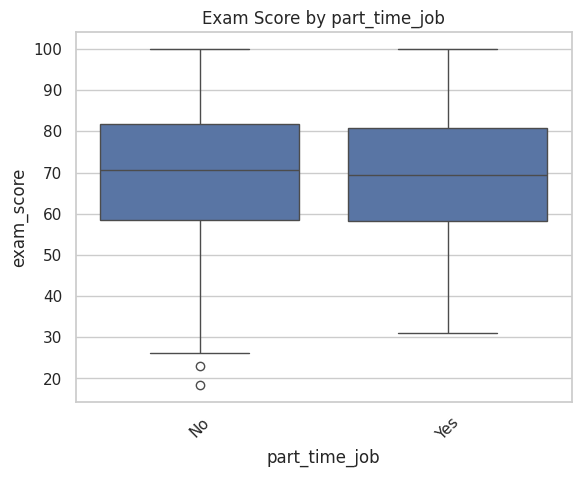

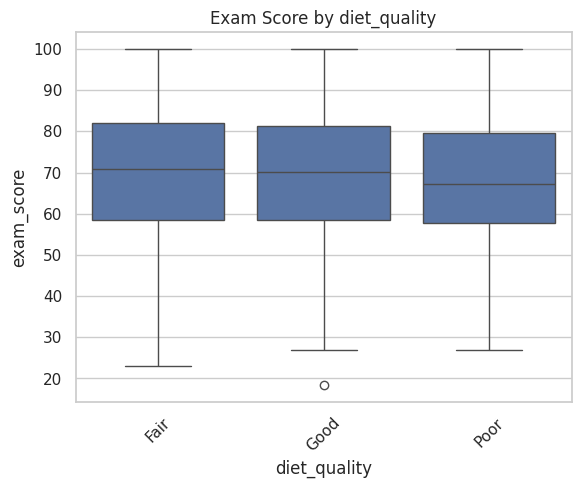

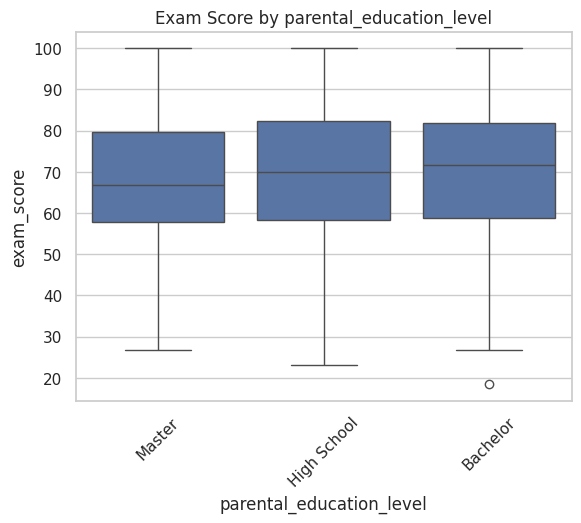

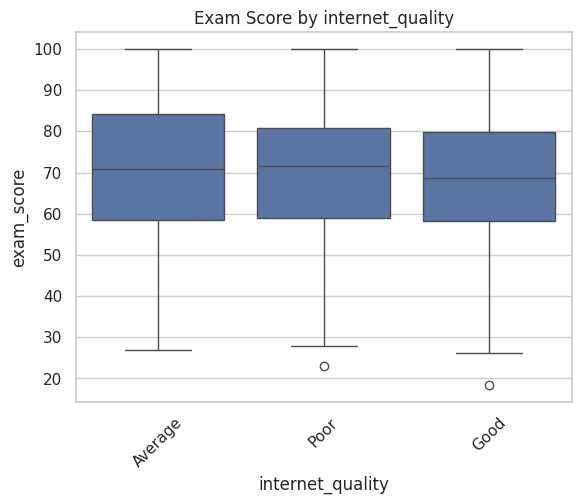

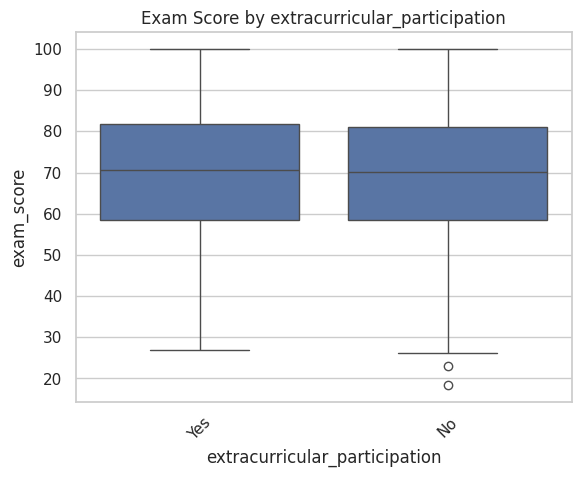

In [26]:
for col in categorical_cols:
    sns.boxplot(data = df, x = col, y= "exam_score")
    plt.title(f"Exam Score by {col}")
    plt.xticks(rotation=45)
    plt.show()

In [27]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn. linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn. tree import DecisionTreeRegressor

# features that i will use for model traning

In [28]:
features=["study_hours_per_day", 'attendance_percentage', 'mental_health_rating','sleep_hours','part_time_job' ]

In [29]:
target = 'exam_score'

In [30]:
df_model = df[features + [target]].copy()


df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,No,56.2
1,6.9,97.3,8,4.6,No,100.0
2,1.4,94.8,1,8.0,No,34.3
3,1.0,71.0,1,9.2,No,26.8
4,5.0,90.9,1,4.9,No,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,7.5,No,76.1
996,2.9,86.0,6,6.8,Yes,65.9
997,3.0,61.9,9,6.5,No,64.4
998,5.4,100.0,1,7.6,Yes,69.7


In [31]:
le = LabelEncoder()

df_model["part_time_job"] = le.fit_transform(df_model["part_time_job"])

df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,0,56.2
1,6.9,97.3,8,4.6,0,100.0
2,1.4,94.8,1,8.0,0,34.3
3,1.0,71.0,1,9.2,0,26.8
4,5.0,90.9,1,4.9,0,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,7.5,0,76.1
996,2.9,86.0,6,6.8,1,65.9
997,3.0,61.9,9,6.5,0,64.4
998,5.4,100.0,1,7.6,1,69.7


In [35]:
X = df_model[features]

y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [33]:
len(y_test)

182

In [34]:
len(y_train)

727

# model traning

In [38]:
models = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {}
    },
    "DecisionTree" : {
        "model" : DecisionTreeRegressor(),
        "params": {"max_depth": [3,5,10], "min_samples_split": [2,5]}
    },
    "RandomForest": {
        "model": RandomForestRegressor(),
        "params":{"n_estimators": [ 50,100], "max_depth": [5,10]}
    }
}

In [39]:
best_models =[]

In [40]:
for name, config in models.items():
    print(f"Training {name}")

    grid = GridSearchCV(config["model"],config["params"], cv= 5, scoring="neg_mean_squared_error")
    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)
    rmse= np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    best_models.append({
    "model":name,
    "best_params" : grid.best_params_,
    "rmse" : rmse,
    "r2":r2
    })

Training LinearRegression
Training DecisionTree
Training RandomForest


In [41]:
best_models

[{'model': 'LinearRegression',
  'best_params': {},
  'rmse': np.float64(7.6680060854760725),
  'r2': 0.7971312365606074},
 {'model': 'DecisionTree',
  'best_params': {'max_depth': 5, 'min_samples_split': 5},
  'rmse': np.float64(8.260716517822027),
  'r2': 0.7645570330916007},
 {'model': 'RandomForest',
  'best_params': {'max_depth': 10, 'n_estimators': 100},
  'rmse': np.float64(7.901280817075723),
  'r2': 0.784600208446279}]

In [42]:
results_df = pd.DataFrame(best_models)


In [43]:
results_df.sort_values(by="rmse")


,model,best_params,rmse,r2
0,LinearRegression,{},7.668006,0.797131
2,RandomForest,"{'max_depth': 10, 'n_estimators': 100}",7.901281,0.784600
1,DecisionTree,"{'max_depth': 5, 'min_samples_split': 5}",8.260717,0.764557


In [44]:
import joblib

best_row = results_df.sort_values(by="rmse").iloc[0]


In [45]:
best_row


,0
model,LinearRegression
best_params,{}
rmse,7.668006
r2,0.797131


In [46]:
best_model_name = best_row["model"]

In [47]:
best_model_name

'LinearRegression'

In [48]:
best_model_config = models[best_model_name]

In [49]:
best_model_config

{'model': LinearRegression(), 'params': {}}

In [52]:
final_model = best_model_config["model"]

In [53]:
final_model.fit(X,y)


LinearRegression()

In [54]:
joblib.dump(final_model, "best_model.pkl")

['best_model.pkl']

In [55]:
joblib. load("best_model.pkl").predict(X_test)


array([ 86.30137744,  63.2526023 ,  90.09302039,  82.34672584,
        66.85495635,  76.48969124,  66.2175741 ,  77.0077602 ,
        59.41323383,  61.7913346 ,  38.72620623,  76.62284649,
        58.27705943,  71.10976502,  55.7323605 ,  68.38334944,
        74.30904731,  81.11499936, 100.28724338,  55.22074637,
        83.15935166,  55.57788334,  63.56874464,  85.77985132,
        70.22148331,  69.0659914 ,  59.74918922,  57.45957817,
        62.09636584, 102.05443373,  54.27941821,  64.13092859,
       100.91762465,  86.04159457,  85.9407813 ,  60.36098639,
        66.64007487,  74.5771561 ,  62.07233324,  53.49737655,
        81.86755532,  39.79507284,  48.1785658 ,  67.76353877,
        43.14340981,  44.89569851,  65.58871377,  73.20131605,
        77.38615468,  47.31343716,  83.87763264,  55.02624368,
        77.48107335,  83.15536594,  65.38478204,  67.28188611,
        53.35891573,  71.17382137,  57.48846515,  78.07562614,
        85.89629743,  67.37387105,  72.40322861,  96.41